# Spherical Diffusion PDE and Implicit Finite Difference Method

## 1. Governing PDE

Lithium diffusion inside a spherical particle is governed by Fick’s second law in spherical coordinates:

$$
\frac{\partial C}{\partial t}
=
D\left(
\frac{\partial^2 C}{\partial r^2}
+
\frac{2}{r}\frac{\partial C}{\partial r}
\right)
$$

where:

- $C(r,t)$ = lithium concentration inside the particle
- $D$ = solid-state diffusivity
- $r$ = radial coordinate
- $t$ = time

---

# 2. Boundary Conditions

## (a) Symmetry at the centre

At $r=0$:

$$
\frac{\partial C}{\partial r}=0
$$

This ensures no singularity and no flux through the centre.

---

## (b) Flux boundary condition at the surface

At $r=a$:

$$
-D\frac{\partial C}{\partial r}\Big|_{r=a}=j
$$

where:

- $a$ = particle radius
- $j$ = applied molar flux

For charging (lithium insertion):

$$
j<0
$$

For discharging:

$$
j>0
$$

---

# 3. Variable Transformation

The spherical PDE contains the singular term:

$$
\frac{2}{r}\frac{\partial C}{\partial r}
$$

To remove this singularity, define:

$$
u(r,t)=rC(r,t)
$$

Therefore:

$$
C=\frac{u}{r}
$$

---

# 4. Transforming the PDE

Differentiate:

$$
\frac{\partial u}{\partial r}
=
C+r\frac{\partial C}{\partial r}
$$

and

$$
\frac{\partial^2 u}{\partial r^2}
=
2\frac{\partial C}{\partial r}
+
r\frac{\partial^2 C}{\partial r^2}
$$

Multiply the original PDE by $r$:

$$
r\frac{\partial C}{\partial t}
=
D\left(
r\frac{\partial^2 C}{\partial r^2}
+
2\frac{\partial C}{\partial r}
\right)
$$

Using the expression for $\frac{\partial^2 u}{\partial r^2}$:

$$
\frac{\partial u}{\partial t}
=
D\frac{\partial^2 u}{\partial r^2}
$$

The transformed equation becomes the standard 1D Cartesian diffusion equation.

---

# 5. Boundary Conditions in Terms of $u$

## (a) Centre boundary condition

Since:

$$
u=rC
$$

at $r=0$:

$$
u(0,t)=0
$$

This becomes a Dirichlet boundary condition.

---

## (b) Surface flux boundary condition

Starting from:

$$
-D\frac{\partial C}{\partial r}=j
$$

Since:

$$
C=\frac{u}{r}
$$

then:

$$
\frac{\partial C}{\partial r}
=
\frac{1}{r}\frac{\partial u}{\partial r}
-
\frac{u}{r^2}
$$

At $r=a$:

$$
-D\left(
\frac{1}{a}\frac{\partial u}{\partial r}
-
\frac{u(a)}{a^2}
\right)
=j
$$

Rearranging:

$$
\frac{\partial u}{\partial r}\Big|_{r=a}
=
\frac{u(a)}{a}
-
\frac{a}{D}j
$$

This is the transformed surface boundary condition.

---

# 6. Time Discretisation — Backward Euler

The transformed PDE is:

$$
\frac{\partial u}{\partial t}
=
D\frac{\partial^2 u}{\partial r^2}
$$

Using Backward Euler:

$$
\frac{\partial u}{\partial t}
\approx
\frac{u_i^{n+1}-u_i^n}{\Delta t}
$$

where:

- $n$ = old timestep
- $n+1$ = new timestep

---

# 7. Spatial Discretisation — Central Difference

Second derivative:

$$
\frac{\partial^2 u}{\partial r^2}
\approx
\frac{
u_{i+1}^{n+1}
-
2u_i^{n+1}
+
u_{i-1}^{n+1}
}{
(\Delta r)^2
}
$$

---

# 8. Substitute into PDE

Substitute both discretisations:

$$
\frac{
u_i^{n+1}-u_i^n
}{
\Delta t
}
=
D
\frac{
u_{i+1}^{n+1}
-
2u_i^{n+1}
+
u_{i-1}^{n+1}
}{
(\Delta r)^2
}
$$

Multiply by $\Delta t$:

$$
u_i^{n+1}-u_i^n
=
\frac{D\Delta t}{(\Delta r)^2}
\left(
u_{i+1}^{n+1}
-
2u_i^{n+1}
+
u_{i-1}^{n+1}
\right)
$$

Define:

$$
c=\frac{D\Delta t}{(\Delta r)^2}
$$

Then:

$$
u_i^{n+1}-u_i^n
=
c
\left(
u_{i+1}^{n+1}
-
2u_i^{n+1}
+
u_{i-1}^{n+1}
\right)
$$

Expand RHS:

$$
u_i^{n+1}-u_i^n
=
cu_{i+1}^{n+1}
-
2cu_i^{n+1}
+
cu_{i-1}^{n+1}
$$

Bring all new timestep terms to the left:

$$
-c\,u_{i-1}^{n+1}
+
(1+2c)\,u_i^{n+1}
-
c\,u_{i+1}^{n+1}
=
u_i^n
$$

This is the implicit finite difference equation.

---

# 9. Matrix Form

For every interior node:

$$
-c\,u_{i-1}^{n+1}
+
(1+2c)\,u_i^{n+1}
-
c\,u_{i+1}^{n+1}
=
u_i^n
$$

This produces a tridiagonal matrix system:

$$
A u^{n+1}=u^n
$$

with matrix:

$$
A=
\begin{bmatrix}
1+2c & -c & 0 & 0 & \cdots \\
-c & 1+2c & -c & 0 & \cdots \\
0 & -c & 1+2c & -c & \cdots \\
0 & 0 & -c & 1+2c & \cdots \\
\vdots & \vdots & \vdots & \vdots & \ddots
\end{bmatrix}
$$

---

# 10. Left Boundary Condition in Matrix Form

At the centre:

$$
u(0,t)=0
$$

Therefore:

$$
u_0^{n+1}=0
$$

This replaces the first matrix row with:

$$
[1,0,0,\dots]
$$

and RHS:

$$
0
$$

---

# 11. Surface Boundary Condition Using a Ghost Cell

At the surface:

$$
\frac{\partial u}{\partial r}
=
\frac{u(a)}{a}
-
\frac{a}{D}j
$$

Approximate derivative using a ghost node:

$$
\frac{u_{nx}-u_{nx-1}}{\Delta r}
=
\frac{u_{\text{face}}}{a}
-
\frac{a}{D}j
$$

Approximate face value:

$$
u_{\text{face}}
\approx
\frac{u_{nx-1}+u_{nx}}{2}
$$

Substitute:

$$
\frac{u_{nx}-u_{nx-1}}{\Delta r}
=
\frac{u_{nx-1}+u_{nx}}{2a}
-
\frac{a}{D}j
$$

Solving for the ghost node:

$$
u_{nx}
\approx
u_{nx-1}\left(1+\frac{\Delta r}{a}\right)
-
\frac{\Delta r\,a}{D}j
$$

---

# 12. Modify Final Matrix Row

The last-node equation is:

$$
-c\,u_{nx-2}^{n+1}
+
(1+2c)\,u_{nx-1}^{n+1}
-
c\,u_{nx}^{n+1}
=
u_{nx-1}^n
$$

Substitute the ghost-node expression:

$$
u_{nx}
=
u_{nx-1}\left(1+\frac{\Delta r}{a}\right)
-
\frac{\Delta r\,a}{D}j
$$

Then:

$$
-c\,u_{nx-2}^{n+1}
+
\left[
1+2c-c\left(1+\frac{\Delta r}{a}\right)
\right]
u_{nx-1}^{n+1}
=
u_{nx-1}^n
-
c\frac{\Delta r\,a}{D}j
$$

Simplify:

$$
1+2c-c-c\frac{\Delta r}{a}
=
1+c\left(1-\frac{\Delta r}{a}\right)
$$

Therefore the final diagonal term becomes:

$$
1+c\left(1-\frac{\Delta r}{a}\right)
$$

which matches the code:

```python
main[-1] = 1 + c * (1 - dr/a)
```

# Constant Current (CC) Butler–Volmer Simplification

In constant-current (CC) charging/discharging, the applied flux $j$ is fixed.

The symmetric Butler–Volmer equation is:

$$
j
=
\frac{2i_0}{F}
\sinh\left(
\frac{F\eta}{2RT}
\right)
$$

where:

- $j$ = molar flux $(\mathrm{mol/m^2/s})$
- $i_0$ = exchange current density $(\mathrm{A/m^2})$
- $F$ = Faraday constant
- $R$ = gas constant
- $T$ = temperature
- $\eta$ = overpotential

---

# Rearranging for Overpotential

Multiply both sides by $\dfrac{F}{2i_0}$:

$$
\frac{Fj}{2i_0}
=
\sinh\left(
\frac{F\eta}{2RT}
\right)
$$

Apply inverse hyperbolic sine:

$$
\sinh^{-1}\left(
\frac{Fj}{2i_0}
\right)
=
\frac{F\eta}{2RT}
$$

Solve for $\eta$:

$$
\boxed{
\eta
=
\frac{2RT}{F}
\sinh^{-1}\left(
\frac{Fj}{2i_0}
\right)
}
$$

---

# Exchange Current Density

The concentration-dependent exchange current density used in the code is:

$$
i_0
=
m_{\mathrm{ref}}
\sqrt{
c_e\,c_s\,(c_{\max}-c_s)
}
$$

where:

- $m_{\mathrm{ref}}$ = kinetic rate constant
- $c_e$ = electrolyte concentration
- $c_s$ = surface lithium concentration
- $c_{\max}$ = maximum solid concentration

---

# Final CC Overpotential Expression

Substituting $i_0(c_s)$:

$$
\boxed{
\eta
=
\frac{2RT}{F}
\sinh^{-1}
\left(
\frac{
Fj
}{
2m_{\mathrm{ref}}
\sqrt{
c_e\,c_s\,(c_{\max}-c_s)
}
}
\right)
}
$$

This equation is used in CC simulations to compute the overpotential required to sustain a fixed applied current/flux.

CC charging at 1C  (j = -1.2218e-05 mol/m²/s)
Initial SoC : 3.79%
Matrix factorised. Running...

Simulation stopped: max time
Final SoC                  : 86.92%
Final surface concentration: 23258.48 mol/m³
Final overpotential        : -97.3 mV


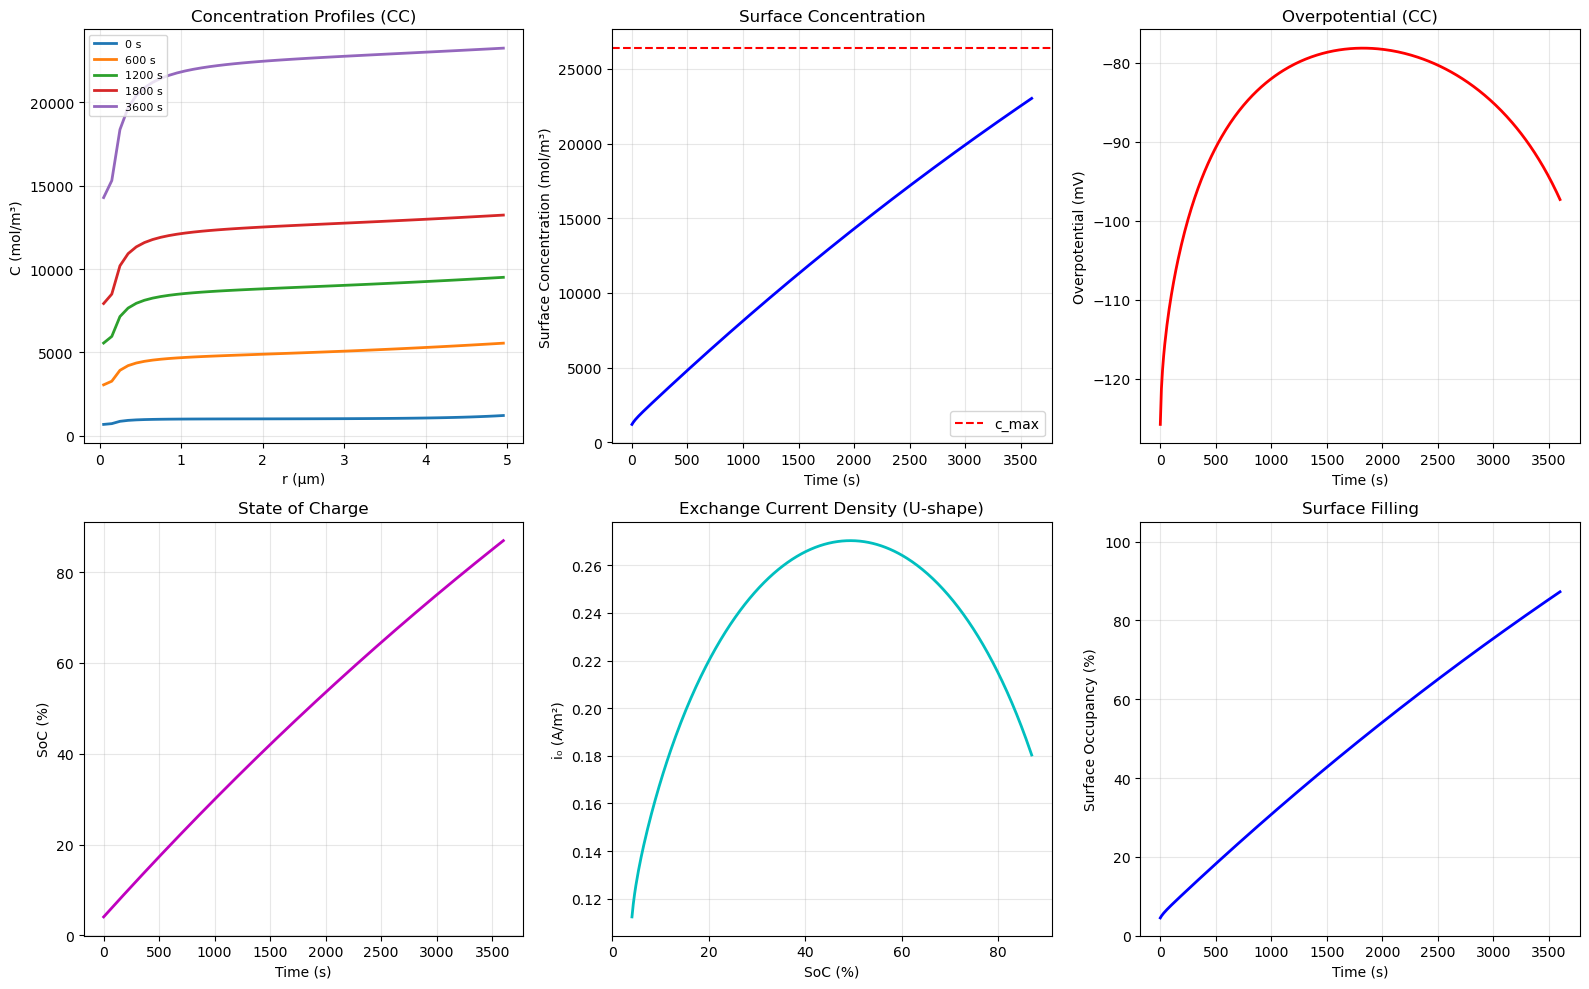

In [ ]:
#CC BMV model
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import factorized

 
# Physical constants
 
F = 96485 #Faraday Constant
R = 8.314 #Gas Constant
T = 298.15 #Temparature

 
# Particle properties (graphite)
 
a = 5e-6             # particle radius (m)
D_val = 3.9e-14      # solid-state diffusivity (m²/s)
c_max = 26390        # max lithium concentration (mol/m³)
c_init = 1000        # initial concentration (mol/m³) — ~3.8% SoC
k = 6.48e-7          # Rate Constant
c_e = 1000           #Electrolyte concentration​ (mol/m³) = 1 M LiPF₆
 
# Operating condition — Constant Current (CC)
 
C_rate = 1           # 1C charging (current would fully charge (or discharge) the battery in exactly 1 hour)(lithium insertion, negative flux)

# Theoretical 1C flux for a sphere:
# Total capacity = (4/3) π a^3 * c_max * F [C]
# 1C current = capacity / 3600 [A]
# Surface area = 4 π a^2
# Molar flux j = I / (F * A) = (a * c_max) / (3 * 3600)  [mol/m²/s]
j_applied = - (a * c_max * C_rate) / (3 * 3600)   # negative = insertion

# Cut‑off conditions
SOC_max = 0.95         # stop charging at 95% SoC
eta_max = 0.5          # stop if overpotential exceeds 0.5 V (safety)

 
# Exchange current density   
 
def i0_func(c_s): 
    c_s = np.clip(c_s, 1e-12, c_max - 1e-12) #If cs=0 then i0=0 then overpotential would be divided by zero
    return k*np.sqrt(c_e* c_s * (c_max - c_s))

# Inverse Butler‑Volmer: given flux j, find overpotential η
# j = (2*i0/F) * sinh( F η / (2 R T) )
# → η = (2 R T / F) * arcsinh( (F * j) / (2 * i0) )
def overpotential_from_j(c_s, j_applied):
    i0 = i0_func(c_s)
    # Clamp to avoid singularity when i0 → 0
    if i0 < 1e-16:
        return np.sign(j_applied) * 10   # large default
    arg = F * j_applied / (2 * i0)
    return (2 * R * T / F) * np.arcsinh(arg) 

 
# Mesh  (u = C·r formulation)
 
nx = 50
dr = a / nx
r  = (np.arange(nx) + 0.5) * dr   # cell centres, shape (nx,)


 
# Build the implicit diffusion matrix (identical to CV version)
 
def build_A(dt, dr, a, nx):
    c = D_val * dt / dr**2
    main  = np.full(nx, 1.0 + 2.0*c)
    lower = np.full(nx - 1, -c)
    upper = np.full(nx - 1, -c)

#      ┌                                                         ┐
#      │ main[0]   upper[0]    0        0      ...       0       │
#      │ lower[0]  main[1]  upper[1]    0      ...       0       │
# A =  │    0      lower[1]  main[2]  upper[2] ...       0       │
#      │    0         0      lower[2]  main[3] ...       0       │
#      │   ...       ...       ...      ...    ...     upper[47] │
#      │    0         0         0        0   lower[48] main[49]  │
#      └                                                         ┘


    main[0] = 1.0
    upper[0] = 0.0
    # At the centre -u(0,t)=0 because:u=rC and r=0
    #First row becomes:u0n+1=0
    # So the matrix row is:
    # [1,0,0,… ]

    

    # Ghost-cell Neumann at right: flux j is known (constant)
    main[-1] = 1.0 + c * (1.0 - dr / a)

    return diags([lower, main, upper], [-1, 0, 1], format='csr')

 
# Time stepping
 
sim_time = 3600.0     # 1 hour maximum
dt       = 10.0        # seconds
steps    = int(sim_time / dt)

A       = build_A(dt, dr, a, nx)
solve_A = factorized(A) # returns a callable function solve_A(rhs) that solves the system: A⋅un+1=rhs
# #by doing:
#     Forward substitution using L: solve L⋅y=rhs for y
#     Back substitution using U: solve U⋅un+1=y for u^{n+1}

u = c_init * r         # initial condition

# Logging arrays
log_size   = steps + 1
time_log   = np.linspace(0, sim_time, log_size)
j_log      = np.full(log_size, j_applied)   # creates an array pre‑filled with the constant applied flux value, to serve as a log of the flux at every timestep.
c_surf_log = np.empty(log_size)
soc_log    = np.empty(log_size)
eta_log    = np.empty(log_size)

# Quadrature weights for volume average
dV = r**2

print(f"CC charging at {C_rate}C  (j = {j_applied:.4e} mol/m²/s)")
print(f"Initial SoC : {c_init/c_max*100:.2f}%")
print(f"Matrix factorised. Running...\n")

# Store snapshot profiles at selected times
snapshot_times = [0, 600, 1200, 1800, 3600]   # seconds
snapshot_steps = {int(t / dt) for t in snapshot_times if t <= sim_time}
snapshots = {}

stop_reason = "max time"
for step in range(steps + 1):
    # Current surface concentration
    c_surf = u[-1] / a
    c_surf = np.clip(c_surf, 1e-12, c_max - 1e-12)

    # Compute overpotential required to sustain the constant flux
    eta = overpotential_from_j(c_surf, j_applied)

    # RHS for diffusion step (j_applied is directly used in the BC)
    rhs     = u.copy()
    rhs[0]  = 0.0
    rhs[-1] -= dt * a / dr * j_applied
    u = solve_A(rhs)

    # Logging
    c_surf_new = np.clip(u[-1] / a, 1e-12, c_max - 1e-12)
    c_surf_log[step] = c_surf_new
    eta_log[step] = eta

    # SoC from volume average
    C_profile    = u / r
    C_profile[0] = (4*C_profile[1] - C_profile[2]) / 3   # quadratic extrapolation
    soc_log[step] = np.dot(C_profile, dV) / dV.sum() / c_max

    if step in snapshot_steps:
        snapshots[step * dt] = C_profile.copy()

    # Check cut‑off conditions
    if soc_log[step] >= SOC_max:
        stop_reason = f"SoC limit ({SOC_max*100:.0f}%) reached at t = {step*dt:.0f} s"
        # Trim logs
        time_log = time_log[:step+1]
        c_surf_log = c_surf_log[:step+1]
        soc_log = soc_log[:step+1]
        eta_log = eta_log[:step+1]
        j_log = j_log[:step+1]
        break
    if np.abs(eta_log[step]) > eta_max:
        stop_reason = f"Overpotential limit ({eta_max} V) reached at t = {step*dt:.0f} s"
        time_log = time_log[:step+1]
        c_surf_log = c_surf_log[:step+1]
        soc_log = soc_log[:step+1]
        eta_log = eta_log[:step+1]
        j_log = j_log[:step+1]
        break

 
# Final state
 
C_final    = u / r
C_final[0] = (4*C_final[1] - C_final[2]) / 3 
SoC_final  = np.dot(C_final, dV) / dV.sum() / c_max

print("Simulation stopped:", stop_reason)
print(f"Final SoC                  : {SoC_final*100:.2f}%")
print(f"Final surface concentration: {C_final[-1]:.2f} mol/m³")
print(f"Final overpotential        : {eta_log[-1]*1000:.1f} mV")

 
# PLOTS
 
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Concentration profiles
ax = axes[0, 0]
for t_snap in snapshot_times:
    if t_snap in snapshots:
        ax.plot(r * 1e6, snapshots[t_snap], linewidth=2, label=f'{t_snap:.0f} s')
ax.set(xlabel='r (µm)', ylabel='C (mol/m³)', title='Concentration Profiles (CC)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 2. Surface concentration vs time
ax = axes[0, 1]
ax.plot(time_log, c_surf_log, 'b-', linewidth=2)
ax.axhline(c_max, color='r', linestyle='--', label='c_max')
ax.set(xlabel='Time (s)', ylabel='Surface Concentration (mol/m³)',
       title='Surface Concentration')
ax.legend()
ax.grid(alpha=0.3)

# 3. Overpotential vs time
ax = axes[0, 2]
ax.plot(time_log, eta_log * 1000, 'r-', linewidth=2)
ax.set(xlabel='Time (s)', ylabel='Overpotential (mV)', title='Overpotential (CC)')
ax.grid(alpha=0.3)

# 4. SoC vs time
ax = axes[1, 0]
ax.plot(time_log, soc_log * 100, 'm-', linewidth=2)
ax.set(xlabel='Time (s)', ylabel='SoC (%)', title='State of Charge')
ax.grid(alpha=0.3)

# 5. Exchange current density vs SoC
i0_vals = i0_func(c_surf_log)
ax = axes[1, 1]
ax.plot(soc_log * 100, i0_vals, 'c-', linewidth=2)
ax.set(xlabel='SoC (%)', ylabel='i₀ (A/m²)', title='Exchange Current Density (U‑shape)')
ax.grid(alpha=0.3)

# 6. Surface occupancy
ax = axes[1, 2]
ax.plot(time_log, c_surf_log / c_max * 100, 'b-', linewidth=2)
ax.set(xlabel='Time (s)', ylabel='Surface Occupancy (%)', title='Surface Filling')
ax.grid(alpha=0.3)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

# Constant Voltage (CV) Butler–Volmer Simplification

In constant-voltage (CV) charging/discharging, the overpotential $\eta$ is fixed.

The symmetric Butler–Volmer equation is:

$$
j
=
\frac{2i_0}{F}
\sinh\left(
\frac{F\eta}{2RT}
\right)
$$

where:

- $j$ = molar flux $(\mathrm{mol/m^2/s})$
- $i_0$ = exchange current density $(\mathrm{A/m^2})$
- $F$ = Faraday constant
- $R$ = gas constant
- $T$ = temperature
- $\eta$ = overpotential

---

# Exchange Current Density

The concentration-dependent exchange current density is:

$$
i_0
=
m_{\mathrm{ref}}
\sqrt{
c_e\,c_s\,(c_{\max}-c_s)
}
$$

where:

- $m_{\mathrm{ref}}$ = kinetic rate constant
- $c_e$ = electrolyte concentration
- $c_s$ = surface lithium concentration
- $c_{\max}$ = maximum lithium concentration

---

# Substituting into Butler–Volmer Equation

Substitute $i_0(c_s)$ into Butler–Volmer:

$$
j
=
\frac{
2m_{\mathrm{ref}}
\sqrt{
c_e\,c_s\,(c_{\max}-c_s)
}
}{F}
\sinh\left(
\frac{F\eta}{2RT}
\right)
$$

Since CV operation keeps $\eta$ constant, define:

$$
S
=
\sinh\left(
\frac{F\eta}{2RT}
\right)
$$

which is constant during the simulation.

Then:

$$
j
=
\frac{
2m_{\mathrm{ref}}S
}{F}
\sqrt{
c_e\,c_s\,(c_{\max}-c_s)
}
$$

---

# Final CV Flux Expression

$$
\boxed{
j(c_s)
=
\frac{
2m_{\mathrm{ref}}
}{F}
\sqrt{
c_e\,c_s\,(c_{\max}-c_s)
}
\,
\sinh\left(
\frac{F\eta}{2RT}
\right)
}
$$

This equation is used in CV simulations to compute the surface molar flux from the fixed overpotential and the evolving surface concentration.

---

# Physical Interpretation

Under CV conditions:

- $\eta$ is fixed
- the $\sinh$ term is constant
- the flux changes only because $i_0(c_s)$ changes

As the particle fills:

$$
c_s \to c_{\max}
$$

therefore:

$$
(c_{\max}-c_s)\to 0
$$

which causes:

$$
i_0 \to 0
$$

and hence:

$$
j \to 0
$$

This produces the characteristic **CV current taper** observed during battery charging.

c:\Users\admin\miniconda3\envs\fipy_env\lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve


Fixed overpotential : 100 mV
Initial SoC         : 3.79%
Steps: 2000  |  dt: 1.0 s  |  total: 2000 s
Matrix factored once — reused every step.

Starting CV simulation...

Simulation complete.
Final SoC                  : -0.00%
Final surface concentration: -0.00 mol/m³
Final flux                 : 2.3665e-13 mol/m²/s


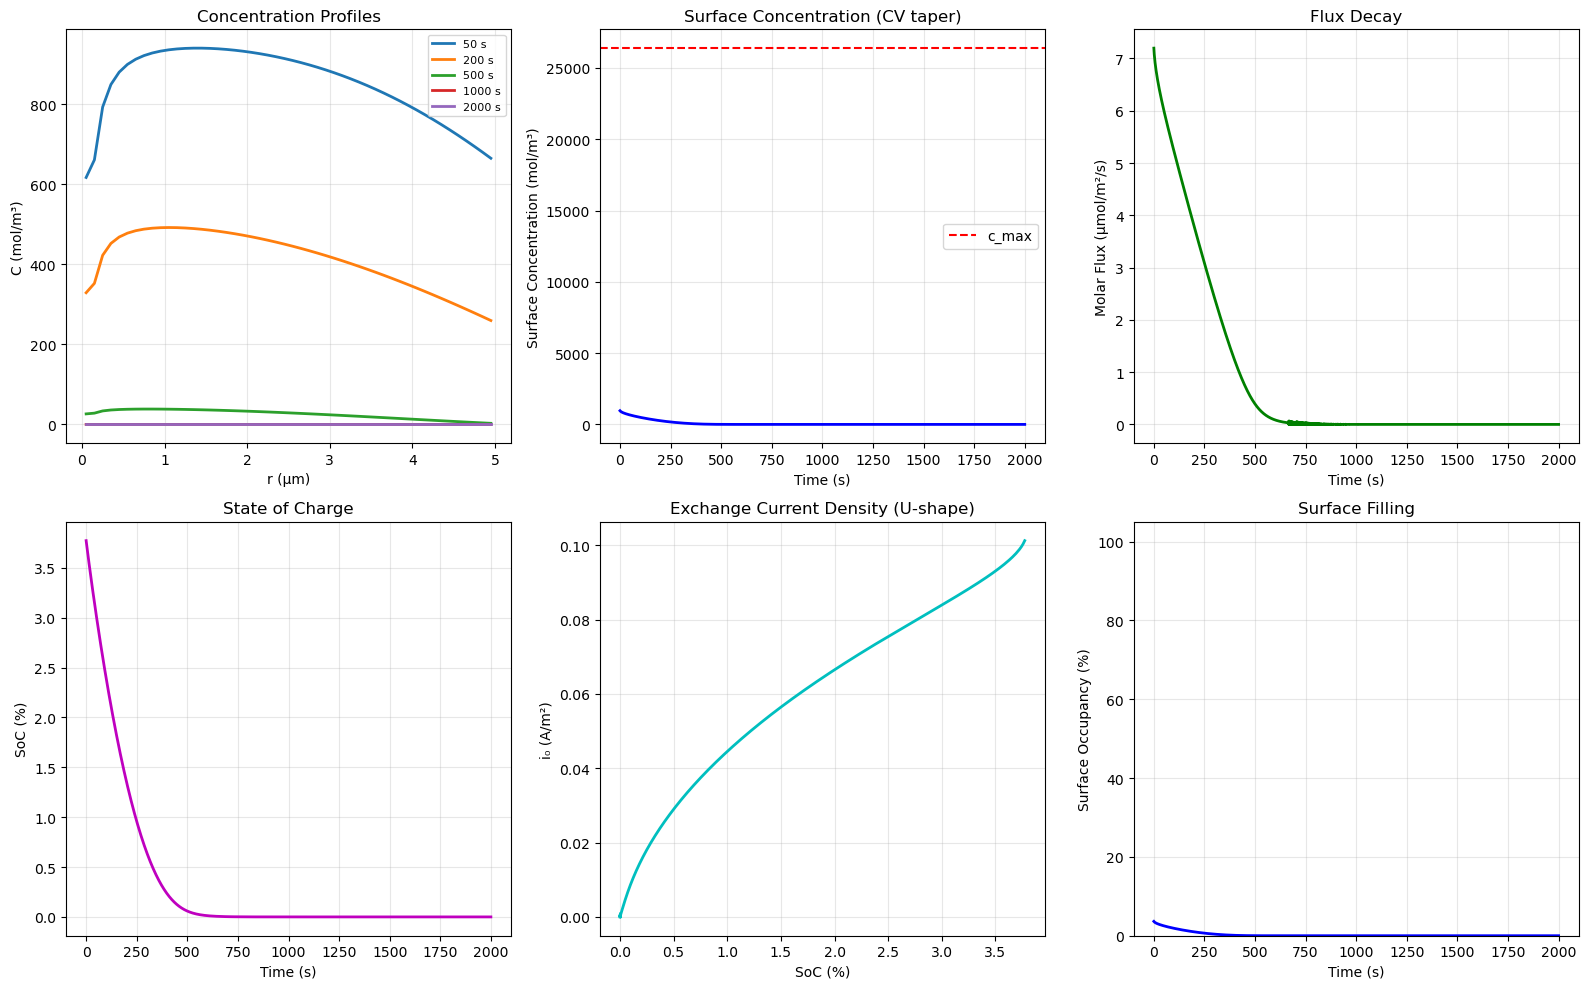

In [ ]:
#CV BMV model
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve, factorized

 
# Physical constants
 
F = 96485.0
R = 8.314
T = 298.15

 
# Particle properties (graphite)
 
a = 5e-6             # particle radius (m)
D_val = 3.9e-14      # solid-state diffusivity (m²/s)
c_max = 26390.0      # max lithium concentration (mol/m³)
c_init = 1000.0      # initial concentration (mol/m³) — ~3.8% SoC

 
# Operating condition — Constant Voltage
 
eta_fixed = 0.10     # fixed overpotential (V)

 
# Exchange current density   
 
def i0_func(c_s):
    c_s = np.clip(c_s, 1e-12, c_max - 1e-12)
    return 6.48e-7 * np.sqrt(1000.0 * c_s * (c_max - c_s))

sinh_factor = np.sinh(F * eta_fixed / (2 * R * T))

def j_flux(c_s):
    """Molar flux (mol/m²/s). Positive = lithium leaving particle."""
    return 2.0 * i0_func(c_s) * sinh_factor / F

 
# Mesh  (u = C·r formulation)
 
nx = 50
dr = a / nx
r  = (np.arange(nx) + 0.5) * dr   # cell centres, shape (nx,)
lam = D_val / dr**2                # diffusion number (per unit time)

 
# Build the implicit diffusion matrix — CONSTANT, built once.
#
# PDE:  du/dt = D * d²u/dr²
# Implicit (backward-Euler) stencil for interior nodes i=1..nx-2:
#   (u^{n+1}_i - u^n_i)/dt = D*(u^{n+1}_{i+1} - 2u^{n+1}_i + u^{n+1}_{i-1})/dr²
# → -lam*dt*u_{i-1} + (1+2*lam*dt)*u_i - lam*dt*u_{i+1} = u^n_i
#
# Left BC  (i=0):  u = 0  (Dirichlet, since u=C·r → 0 at r=0)
# Right BC (i=nx-1): ghost-cell elimination.
#   Physical BC:  -D * dC/dr|_{r=a} = j   (j>0 → lithium leaving)
#   In u-space:   du/dr|_{face} = u_face/a - (a/D)*j
#   Ghost node:   u_ghost = u[nx-1]*(1 + dr/a) - (dr*a/D)*j
#   → main diagonal correction: 1 + 2λdt - λdt*(1 + dr/a) = 1 + λdt*(1 - dr/a)
#   → RHS correction each step: rhs[-1] -= λ*dt*(dr*a/D)*j   [j is explicit]
 
def build_A(lam, dt, dr, a, nx):
    c = lam * dt
    main  = np.full(nx, 1.0 + 2.0*c)
    lower = np.full(nx - 1, -c)
    upper = np.full(nx - 1, -c)

    # Dirichlet at left
    main[0]  = 1.0
    upper[0] = 0.0

    # Ghost-cell Neumann at right
    main[-1] = 1.0 + c * (1.0 - dr / a)

    return diags([lower, main, upper], [-1, 0, 1], format='csr')

 
# Time stepping
 
sim_time = 2000.0
dt       = 1.0
steps    = int(sim_time / dt)

A       = build_A(lam, dt, dr, a, nx)
solve_A = factorized(A)           # LU-factor once, reuse every step

u = c_init * r                    # initial condition

snapshot_times = [50, 200, 500, 1000, 2000]
snapshot_steps = {int(t / dt) for t in snapshot_times}
snapshots = {}

log_size   = steps + 1
j_log      = np.empty(log_size)
i0_log     = np.empty(log_size)
c_surf_log = np.empty(log_size)
soc_log    = np.empty(log_size)
time_log   = np.linspace(0, sim_time, log_size)

# Quadrature weights for volume average: ∫C r² dr / ∫r² dr
dV = r**2

print(f"Fixed overpotential : {eta_fixed*1000:.0f} mV")
print(f"Initial SoC         : {c_init/c_max*100:.2f}%")
print(f"Steps: {steps}  |  dt: {dt} s  |  total: {sim_time:.0f} s")
print(f"Matrix factored once — reused every step.\n")
print("Starting CV simulation...\n")

for step in range(steps + 1):

    # Surface concentration from current u
    c_surf = u[-1] / a
    c_surf = np.clip(c_surf, 1e-12, c_max - 1e-12)

    j_old = j_flux(c_surf)

    # RHS = u^n  (Dirichlet and Neumann corrections)
    rhs     = u.copy()
    rhs[0]  = 0.0                                       # Dirichlet left
    rhs[-1] -= lam * dt * (dr * a / D_val) * j_old     # Neumann right (explicit j)

    u = solve_A(rhs)

    # Log
    c_surf_new = np.clip(u[-1] / a, 1e-12, c_max - 1e-12)
    j_log[step]      = j_flux(c_surf_new)
    i0_log[step]     = i0_func(c_surf_new)
    c_surf_log[step] = c_surf_new

    C_profile    = u / r
    C_profile[0] = (4*C_profile[1] - C_profile[2]) / 3  # L'Hôpital at centre
    soc_log[step] = np.dot(C_profile, dV) / dV.sum() / c_max

    if step in snapshot_steps:
        snapshots[step * dt] = C_profile.copy()

 
# Final state
 
C_final    = u / r
C_final[0] = (u[1] - u[0]) / dr
SoC_final  = np.dot(C_final, dV) / dV.sum() / c_max

print("Simulation complete.")
print(f"Final SoC                  : {SoC_final*100:.2f}%")
print(f"Final surface concentration: {C_final[-1]:.2f} mol/m³")
print(f"Final flux                 : {j_log[-1]:.4e} mol/m²/s")

 
# PLOTS
 
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

ax = axes[0, 0]
for t_snap in snapshot_times:
    if t_snap in snapshots:
        ax.plot(r * 1e6, snapshots[t_snap], linewidth=2, label=f'{t_snap:.0f} s')
ax.set(xlabel='r (µm)', ylabel='C (mol/m³)', title='Concentration Profiles')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(time_log, c_surf_log, 'b-', linewidth=2)
ax.axhline(c_max, color='r', linestyle='--', label='c_max')
ax.set(xlabel='Time (s)', ylabel='Surface Concentration (mol/m³)',
       title='Surface Concentration (CV taper)')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 2]
ax.plot(time_log, j_log * 1e6, 'g-', linewidth=2)
ax.set(xlabel='Time (s)', ylabel='Molar Flux (µmol/m²/s)', title='Flux Decay')
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(time_log, soc_log * 100, 'm-', linewidth=2)
ax.set(xlabel='Time (s)', ylabel='SoC (%)', title='State of Charge')
ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(soc_log * 100, i0_log, 'c-', linewidth=2)
ax.set(xlabel='SoC (%)', ylabel='i₀ (A/m²)', title='Exchange Current Density (U‑shape)')
ax.grid(alpha=0.3)

ax = axes[1, 2]
ax.plot(time_log, c_surf_log / c_max * 100, 'b-', linewidth=2)
ax.set(xlabel='Time (s)', ylabel='Surface Occupancy (%)', title='Surface Filling')
ax.grid(alpha=0.3); ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

# Equations for All Plot Parameters

# 1. Concentration Profile

The concentration profile inside the spherical particle is:

$$
C(r,t)=\frac{u(r,t)}{r}
$$

where:

- $u=rC$
- $r$ = radial position
- $t$ = time

This is plotted as:

$$
C \text{ vs } r
$$

at different times.

---

# 2. Surface Concentration

Surface concentration is the concentration at the particle surface:

$$
c_{\text{surf}}(t)
=
C(r=a,t)
$$

Using the transformed variable:

$$
c_{\text{surf}}
=
\frac{u_{\text{last}}}{a}
$$

where:

- $u_{\text{last}}$ = value at the final radial node
- $a$ = particle radius

This is plotted as:

$$
c_{\text{surf}} \text{ vs } t
$$

---

# 3. Molar Flux

## (a) Constant Voltage (CV)

Flux is obtained from the Butler–Volmer equation:

$$
j
=
\frac{2i_0}{F}
\sinh\left(
\frac{F\eta}{2RT}
\right)
$$

where:

$$
i_0
=
m_{\mathrm{ref}}
\sqrt{
c_e\,c_s\,(c_{\max}-c_s)
}
$$

Substituting:

$$
j(c_s)
=
\frac{
2m_{\mathrm{ref}}
}{F}
\sqrt{
c_e\,c_s\,(c_{\max}-c_s)
}
\,
\sinh\left(
\frac{F\eta}{2RT}
\right)
$$

---

## (b) Constant Current (CC)

Flux is fixed:

$$
j_{\mathrm{applied}}
=
-\frac{
a\,c_{\max}\,C_{\mathrm{rate}}
}{
3\times3600
}
$$

where:

- $C_{\mathrm{rate}}$ = C-rate
- negative sign indicates lithium insertion

This is plotted as:

$$
j \text{ vs } t
$$

---

# 4. State of Charge (SoC)

The volume-averaged concentration is:

$$
\bar{C}
=
\frac{
\int_0^a C(r)\,r^2\,dr
}{
\int_0^a r^2\,dr
}
$$

The State of Charge is:

$$
\mathrm{SoC}
=
\frac{\bar{C}}{c_{\max}}
$$

Percentage form:

$$
\mathrm{SoC}(\%)
=
\frac{\bar{C}}{c_{\max}}
\times100
$$

Discrete numerical form used in code:

$$
\mathrm{SoC}
=
\frac{
\sum_i C_i r_i^2
}{
\sum_i r_i^2
}
\frac{1}{c_{\max}}
$$

This is plotted as:

$$
\mathrm{SoC} \text{ vs } t
$$

---

# 5. Exchange Current Density

The exchange current density is:

$$
i_0
=
m_{\mathrm{ref}}
\sqrt{
c_e\,c_s\,(c_{\max}-c_s)
}
$$

This depends on surface concentration.

It approaches zero when:

$$
c_s \to 0
$$

or

$$
c_s \to c_{\max}
$$

Maximum value occurs near:

$$
c_s \approx \frac{c_{\max}}{2}
$$

This is plotted as:

$$
i_0 \text{ vs SoC}
$$

---

# 6. Surface Filling / Surface Occupancy

Surface filling is the fraction of surface lithium occupancy:

$$
\text{Surface Filling}
=
\frac{c_{\text{surf}}}{c_{\max}}
$$

Percentage form:

$$
\text{Surface Filling (\%)}
=
\frac{c_{\text{surf}}}{c_{\max}}
\times100
$$

This is plotted as:

$$
\text{Surface Filling} \text{ vs } t
$$

---

# 7. Overpotential (CC Simulation)

In constant-current operation, overpotential is obtained from inverse Butler–Volmer:

$$
j
=
\frac{2i_0}{F}
\sinh\left(
\frac{F\eta}{2RT}
\right)
$$

Solving for $\eta$:

$$
\eta
=
\frac{2RT}{F}
\sinh^{-1}
\left(
\frac{Fj}{2i_0}
\right)
$$

Substituting $i_0(c_s)$:

$$
\eta
=
\frac{2RT}{F}
\sinh^{-1}
\left(
\frac{
Fj
}{
2m_{\mathrm{ref}}
\sqrt{
c_e\,c_s\,(c_{\max}-c_s)
}
}
\right)
$$

This is plotted as:

$$
\eta \text{ vs } t
$$